In [1]:
import numpy as np
import pandas as pd


In [2]:
df = pd.read_csv('dataset.csv')
df.head()
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298450 entries, 0 to 298449
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            298450 non-null  object 
 1   latitude                      298450 non-null  float64
 2   longitude                     298450 non-null  float64
 3   location                      295409 non-null  object 
 4   vehicle_number                298450 non-null  object 
 5   vehicle_type                  298450 non-null  object 
 6   description                   0 non-null       float64
 7   violation_type                298450 non-null  object 
 8   offence_code                  298450 non-null  object 
 9   created_datetime              298450 non-null  object 
 10  closed_datetime               0 non-null       float64
 11  modified_datetime             298450 non-null  object 
 12  device_id                     298450 non-nul

In [3]:
subset_counts = df['violation_type'].value_counts()
print(subset_counts)
wrong_parking_df = df[df['violation_type'].str.contains("WRONG PARKING", na=False)]

violation_type
["WRONG PARKING"]                                                                                                                    138764
["NO PARKING"]                                                                                                                       119576
["PARKING IN A MAIN ROAD","WRONG PARKING"]                                                                                             9472
["PARKING IN A MAIN ROAD","NO PARKING"]                                                                                                4818
["WRONG PARKING","DEFECTIVE NUMBER PLATE"]                                                                                             3317
                                                                                                                                      ...  
["NO PARKING","PARKING IN A MAIN ROAD","PARKING NEAR ROAD CROSSING","PARKING OPPOSITE TO ANOTHER PARKED VEHICLE","WRONG PARKING"]         1
["NO 

In [4]:
no_parking_df = df[df['violation_type'].str.contains("NO PARKING", na=False)]

In [5]:
print(f"Wrong Parking: {len(wrong_parking_df)}")
print(f"No Parking: {len(no_parking_df)}")

Wrong Parking: 164977
No Parking: 139050


### checking how much unnecessary metadata present


In [6]:
print(df[['latitude','longitude']].isnull().sum())

latitude     0
longitude    0
dtype: int64


In [12]:
print(df['violation_type'].value_counts().head(50))

violation_type
[WRONG PARKING]                                                                     138764
[NO PARKING]                                                                        119576
[PARKING IN A MAIN ROAD, WRONG PARKING]                                               9472
[PARKING IN A MAIN ROAD, NO PARKING]                                                  4818
[WRONG PARKING, DEFECTIVE NUMBER PLATE]                                               3317
[NO PARKING, PARKING IN A MAIN ROAD]                                                  2449
[NO PARKING, DEFECTIVE NUMBER PLATE]                                                  2380
[WRONG PARKING, PARKING IN A MAIN ROAD]                                               1955
[PARKING ON FOOTPATH, WRONG PARKING]                                                  1190
[NO PARKING, WRONG PARKING]                                                            891
[PARKING IN A MAIN ROAD, WRONG PARKING, NO PARKING]                        

In [13]:
hotspots = (
    parking_df
    .groupby(['latitude','longitude'])
    .size()
    .reset_index(name='violations')
)

hotspots = hotspots.sort_values(
    'violations',
    ascending=False
)

print(hotspots.head(20))

Empty DataFrame
Columns: [latitude, longitude, violations]
Index: []


In [16]:
import ast

def parse_violation(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return [x]
    return []

df['violation_type'] = df['violation_type'].apply(parse_violation)

print(df['violation_type'].iloc[0])
print(type(df['violation_type'].iloc[0]))

['WRONG PARKING', 'PARKING NEAR ROAD CROSSING']
<class 'list'>


In [18]:
parking_keywords = {
    "WRONG PARKING",
    "NO PARKING",
    "DOUBLE PARKING",
    "PARKING IN A MAIN ROAD",
    "PARKING ON FOOTPATH",
    "PARKING NEAR ROAD CROSSING",
    "PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC",
    "PARKING OTHER THAN BUS STOP"
}

In [19]:
parking_df = df[
    df['violation_type'].apply(
        lambda x: any('PARK' in v.upper() for v in x)
    )
]

print(parking_df.shape)

(298450, 24)


In [20]:
print(df[['latitude','longitude']].isna().sum())
print(df[['latitude','longitude']].head())

latitude     0
longitude    0
dtype: int64
    latitude  longitude
0  12.925557  77.618665
1  12.905463  77.700778
2  12.925449  77.618504
3  12.956521  77.518618
4  12.977767  77.580545


In [21]:
parking_df["lat_round"] = parking_df["latitude"].round(4)
parking_df["lon_round"] = parking_df["longitude"].round(4)

hotspots = (
    parking_df
    .groupby(["lat_round", "lon_round"])
    .size()
    .reset_index(name="violations")
    .sort_values("violations", ascending=False)
)

print(hotspots.head(20))

       lat_round  lon_round  violations
34192    12.9810    77.6102         723
34276    12.9811    77.6102         704
30637    12.9772    77.5765         506
34275    12.9811    77.6101         451
25918    12.9717    77.6581         393
34250    12.9811    77.5984         379
51839    13.0353    77.5890         376
27294    12.9735    77.5793         362
51840    13.0353    77.5891         319
51864    13.0354    77.5891         319
34183    12.9810    77.6077         318
51863    13.0354    77.5890         306
30567    12.9771    77.5765         299
34251    12.9811    77.5985         296
12666    12.9397    77.6955         287
21047    12.9641    77.5768         281
34193    12.9810    77.6103         278
36230    12.9840    77.6037         278
10598    12.9339    77.6908         270
55278    13.0714    77.5882         250


In [22]:
!pip install folium

                                              0.0/113.4 kB ? eta -:--:--
                                              0.0/113.4 kB ? eta -:--:--
     ---                                      10.2/113.4 kB ? eta -:--:--
     ----------                            30.7/113.4 kB 325.1 kB/s eta 0:00:01
     --------------------                  61.4/113.4 kB 465.5 kB/s eta 0:00:01
     ------------------------------------ 113.4/113.4 kB 731.6 kB/s eta 0:00:00
                                              0.0/94.1 kB ? eta -:--:--
     ---------------------------------------- 94.1/94.1 kB 5.6 MB/s eta 0:00:00


In [23]:
import folium
from folium.plugins import HeatMap

m = folium.Map(
    location=[
        parking_df["latitude"].mean(),
        parking_df["longitude"].mean()
    ],
    zoom_start=11
)

HeatMap(
    parking_df[["latitude", "longitude"]].values.tolist(),
    radius=12
).add_to(m)

m.save("parking_heatmap.html")

In [24]:
# or im trying to use dbscan

from sklearn.cluster import DBSCAN
import numpy as np

coords = parking_df[["latitude","longitude"]].to_numpy()

db = DBSCAN(
    eps=0.0008,
    min_samples=50
)

parking_df["cluster"] = db.fit_predict(coords)


#ranking them 
cluster_rank = (
    parking_df[parking_df["cluster"] != -1]
    .groupby("cluster")
    .size()
    .reset_index(name="violations")
    .sort_values("violations", ascending=False)
)

print(cluster_rank.head(20))



#finding cluster centers
cluster_centers = (
    parking_df[parking_df["cluster"] != -1]
    .groupby("cluster")[["latitude","longitude"]]
    .mean()
    .reset_index()
)

cluster_centers = cluster_centers.merge(
    cluster_rank,
    on="cluster"
)

print(cluster_centers.head())

for _, row in cluster_centers.head(20).iterrows():
    folium.Marker(
        [row.latitude, row.longitude],
        popup=f"Violations: {row.violations}"
    ).add_to(m)

     cluster  violations
2          2       58958
3          3       25376
5          5       14746
31        31       10289
10        10       10208
32        32       10078
62        62        9007
56        56        6127
24        24        4765
28        28        4739
16        16        4374
7          7        4170
40        40        3478
18        18        2996
26        26        2823
96        96        2776
87        87        2258
33        33        2238
105      105        2173
23        23        2093
   cluster   latitude  longitude  violations
0        0  12.925240  77.618847         593
1        1  12.957320  77.518809         511
2        2  12.971972  77.577592       58958
3        3  12.981966  77.608017       25376
4        4  12.995571  77.612820        1997


In [25]:
df.head()

,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,...,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[WRONG PARKING, PARKING NEAR ROAD CROSSING]","[112,104]",2023-11-20 00:28:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,[NO PARKING],[113],2023-11-24 22:46:46+00,...,82.0,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN,NaN
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[WRONG PARKING, PARKING IN A MAIN ROAD]","[112,107]",2023-11-20 00:27:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,NaN,[NO PARKING],[113],2023-11-16 06:47:46+00,...,26.0,Byatarayanapura,True,No Junction,NaN,NaN,FKN00GL0003,SCOOTER,approved,2023-11-18 23:35:12.428+00
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,NaN,[NO PARKING],[113],2023-11-22 04:56:46+00,...,3.0,Upparpet,True,BTP044 - Sagar Theatre Junction,NaN,NaN,FKN00GL0004,TANKER,approved,2023-11-30 03:11:32.796+00


In [28]:
cluster_rank = (
    parking_df[parking_df["cluster"] != -1]
    .groupby("cluster")
    .size()
    .reset_index(name="violations")
    .sort_values("violations", ascending=False)
)

cluster_centers = (
    parking_df[parking_df["cluster"] != -1]
    .groupby("cluster")[["latitude", "longitude"]]
    .mean()
    .reset_index()
)

cluster_summary = cluster_centers.merge(
    cluster_rank,
    on="cluster"
)

print(cluster_summary.head())

   cluster   latitude  longitude  violations
0        0  12.925240  77.618847         593
1        1  12.957320  77.518809         511
2        2  12.971972  77.577592       58958
3        3  12.981966  77.608017       25376
4        4  12.995571  77.612820        1997


In [30]:
cluster_junction = (
    parking_df[parking_df["cluster"] != -1]
    .groupby("cluster")["junction_name"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
    .reset_index()
)
cluster_summary = cluster_summary.merge(
    cluster_junction,
    on="cluster",
    how="left"
)

print(cluster_summary.head(20))

    cluster   latitude  longitude  violations  \
0         0  12.925240  77.618847         593   
1         1  12.957320  77.518809         511   
2         2  12.971972  77.577592       58958   
3         3  12.981966  77.608017       25376   
4         4  12.995571  77.612820        1997   
5         5  12.995630  77.550405       14746   
6         6  12.976171  77.599369          84   
7         7  13.008475  77.695353        4170   
8         8  12.912170  77.636104        1918   
9         9  12.899702  77.675465         603   
10       10  12.933377  77.690155       10208   
11       11  12.988836  77.592230         265   
12       12  12.917227  77.651721         176   
13       13  12.996329  77.563130         553   
14       14  12.969732  77.640215         924   
15       15  13.005716  77.685832        1319   
16       16  12.943182  77.697829        4374   
17       17  12.841895  77.645802        2008   
18       18  12.992606  77.588945        2996   
19       19  12.9349

In [34]:
parking_df["created_datetime"] = pd.to_datetime(
    parking_df["created_datetime"],
    format="mixed",
    utc=True
)

parking_df["hour"] = parking_df["created_datetime"].dt.hour
print(parking_df[["created_datetime", "hour"]].head())



           created_datetime  hour
0 2023-11-20 00:28:46+00:00     0
1 2023-11-24 22:46:46+00:00    22
2 2023-11-20 00:27:46+00:00     0
3 2023-11-16 06:47:46+00:00     6
4 2023-11-22 04:56:46+00:00     4


In [35]:
cluster_hourly = (
    parking_df[parking_df["cluster"] != -1]
    .groupby(["cluster", "hour"])
    .size()
    .reset_index(name="count")
)

peak_hours = (
    cluster_hourly
    .sort_values("count", ascending=False)
    .groupby("cluster")
    .first()
    .reset_index()
)

print(peak_hours.head(20))

    cluster  hour  count
0         0     4    123
1         1     6    141
2         2     3   6930
3         3     5   4601
4         4    21    571
5         5     2   1663
6         6     0     21
7         7    19    835
8         8     8    350
9         9     5    108
10       10    22   1558
11       11     0     59
12       12     6     33
13       13     4    107
14       14     2    199
15       15     5    210
16       16     2    568
17       17     7    789
18       18    22    706
19       19    21    156


In [36]:
#should i convert it to IST?
parking_df["created_datetime"] = (
    parking_df["created_datetime"]
    .dt.tz_convert("Asia/Kolkata")
)

parking_df["hour"] = parking_df["created_datetime"].dt.hour
# lets verify
print(
    parking_df[
        ["created_datetime", "hour"]
    ].head()
)

           created_datetime  hour
0 2023-11-20 05:58:46+05:30     5
1 2023-11-25 04:16:46+05:30     4
2 2023-11-20 05:57:46+05:30     5
3 2023-11-16 12:17:46+05:30    12
4 2023-11-22 10:26:46+05:30    10


In [37]:
top_clusters = (
    cluster_rank
    .head(10)[["cluster"]]
)

final_table = (
    cluster_summary
    .merge(peak_hours, on="cluster")
    .sort_values("violations", ascending=False)
)

print(
    final_table[
        ["cluster",
         "junction_name",
         "violations",
         "hour"]
    ].head(10)
)

    cluster                       junction_name  violations  hour
2         2         BTP082 - KR Market Junction       58958     3
3         3      BTP051 - Safina Plaza Junction       25376     5
5         5       BTP027 - Modi Bridge Junction       14746     2
31       31                         No Junction       10289     4
10       10                         No Junction       10208    22
32       32                         No Junction       10078     5
62       62    BTP020 - Hosahalli Metro Station        9007     5
56       56                         No Junction        6127     6
24       24                         No Junction        4765    23
28       28  BTP016 - 5th Main Road, RPC Layout        4739     5


In [40]:
final_table = (
    cluster_summary
    .merge(
        peak_hours[["cluster", "hour", "count"]],
        on="cluster",
        how="left"
    )
)

final_table = final_table.sort_values(
    "violations",
    ascending=False
)

print(final_table.head(20))

final_table["peak_time"] = final_table["hour"].apply(
    lambda h: f"{h:02d}:00 - {(h+1)%24:02d}:00"
)

cluster_violation_type = (
    parking_df
    .explode("violation_type")
    .groupby("cluster")["violation_type"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

cluster_violation_type.rename(
    columns={"violation_type":"dominant_violation"},
    inplace=True
)
final_table = final_table.merge(
    cluster_violation_type,
    on="cluster"
)

cluster_station = (
    parking_df
    .groupby("cluster")["police_station"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)

final_table["priority_score"] = (
    final_table["violations"]
    / final_table["violations"].max()
) * 100


     cluster   latitude  longitude  violations  \
2          2  12.971972  77.577592       58958   
3          3  12.981966  77.608017       25376   
5          5  12.995630  77.550405       14746   
31        31  13.010289  77.553338       10289   
10        10  12.933377  77.690155       10208   
32        32  13.000108  77.571178       10078   
62        62  12.974222  77.547267        9007   
56        56  13.071027  77.588414        6127   
24        24  13.185412  77.680092        4765   
28        28  12.967184  77.537878        4739   
16        16  12.943182  77.697829        4374   
7          7  13.008475  77.695353        4170   
40        40  13.035571  77.589065        3478   
18        18  12.992606  77.588945        2996   
26        26  12.973406  77.618473        2823   
96        96  12.963110  77.717217        2776   
87        87  12.944045  77.571313        2258   
33        33  12.928700  77.583080        2238   
105      105  12.981275  77.598473        2173   


In [41]:
import matplotlib.pyplot as plt

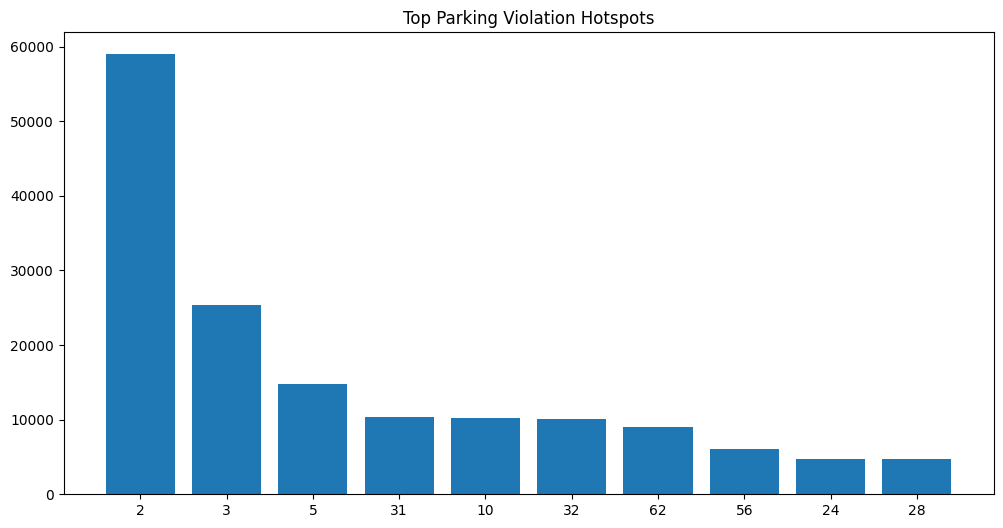

In [42]:
#visualizations

top10 = final_table.head(10)

plt.figure(figsize=(12,6))
plt.bar(
    top10["cluster"].astype(str),
    top10["violations"]
)
plt.title("Top Parking Violation Hotspots")
plt.show()

pivot = (
    parking_df[
        parking_df["cluster"].isin(
            final_table.head(10)["cluster"]
        )
    ]
    .groupby(["cluster","hour"])
    .size()
    .unstack(fill_value=0)
)

In [44]:
!pip install seaborn

                                              0.0/294.9 kB ? eta -:--:--
     -                                        10.2/294.9 kB ? eta -:--:--
     -                                        10.2/294.9 kB ? eta -:--:--
     --                                    20.5/294.9 kB 165.2 kB/s eta 0:00:02
     ------                                51.2/294.9 kB 292.6 kB/s eta 0:00:01
     ----------------------------------     266.2/294.9 kB 1.4 MB/s eta 0:00:01
     -------------------------------------- 294.9/294.9 kB 1.4 MB/s eta 0:00:00


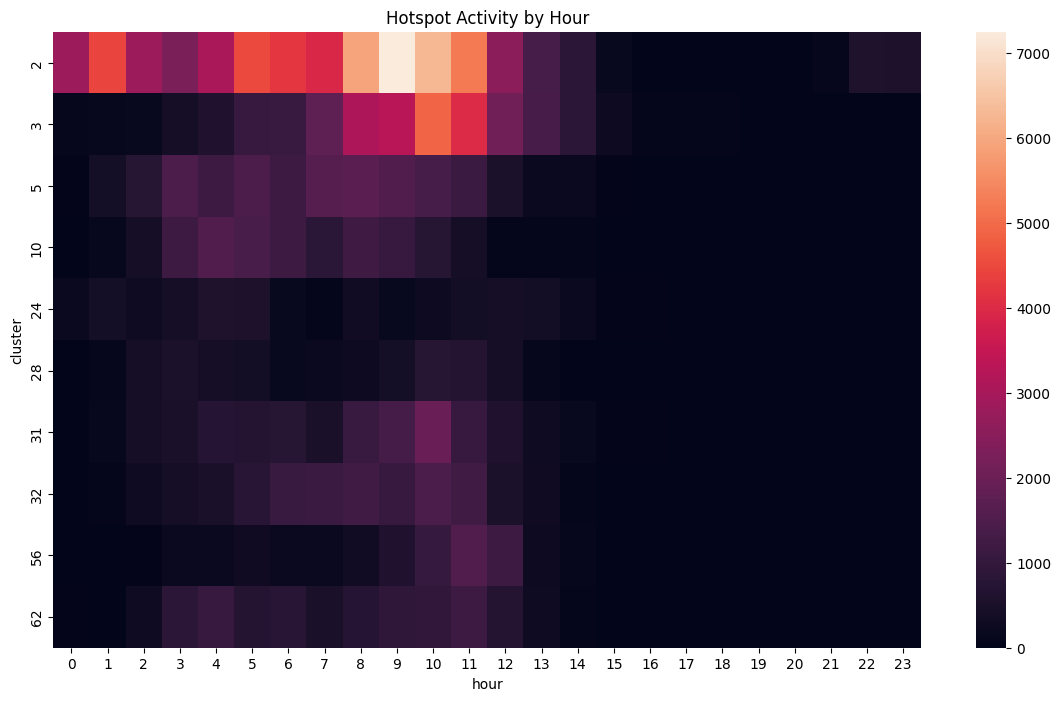

In [45]:
import seaborn as sns

plt.figure(figsize=(14,8))
sns.heatmap(pivot)
plt.title("Hotspot Activity by Hour")
plt.show()